# [3주차] Transformer 과제

- **과제 목적:** 이번 과제는 하나의 흐름 안에서 Transformer의 핵심 연산을 직접 구현하고, 마스킹 전후를 비교한 뒤, BERT와 GPT의 예측 방식을 관찰하는 과제로 출제해봤습니다. 완성된 코드를 실행하는 것에서 끝내지 않고, 실제로 실행하며 얻은 수치와 출력 결과를 근거로 각 개념을 해석하면서 트랜스포머를 이해해주시면 됩니다!

## 전체 흐름

> Scaled Dot-Product Attention 구현 → Causal Mask 적용 → BERT와 GPT 결과 비교 → 전체 해석

### 제출 시 유의사항
- 코드 셀의 `TODO`와 주석의 빈칸을 모두 채워주세요.
- 서술형 답변은 **본인이 실행해 얻은 값이나 출력**을 반드시 이용해서 작성해주세요.
- 마지막 셀의 생성형 AI 활용 내역을 반드시 작성해주세요.


## 0. 환경 설정

아래 셀을 실행하여 필요한 라이브러리를 설치하고 시드를 고정합니다.

In [4]:
!pip -q install transformers torch

import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Hugging Face의 다운로드 진행바/경고를 줄여 과제 출력이 너무 길어지지 않게 합니다.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForCausalLM,
)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


c:\Users\simon\anaconda3\envs\surprise_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


# 1. 필수 과제

## 1-1. Scaled Dot-Product Attention 직접 구현

다음 식을 코드로 구현합니다.

$$
\mathrm{Attention}(Q,K,V)
=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

아래 예제에서 각 행은 하나의 토큰을 나타냅니다. 코드의 빈칸과 주석을 채운 뒤, **Attention Score → Weight → Output**의 흐름을 확인해주세요.


In [5]:
# 세 토큰의 Q, K, V 예시
Q = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

# 첫 번째 Query에서 최대 Attention이 하나만 나오도록 세 번째 Key를 [0.5, 0.5]로 둡니다.
K = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.5, 0.5],
])

V = torch.tensor([
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0],
])


def scaled_dot_product_attention(Q, K, V, mask=None):
    # [빈칸] d_k는 어떤 벡터의 차원을 뜻하는가?
    # 답: Query와 key vector의 차원으로 이 경우엔 2차원을 뜻한다.
    d_k = Q.size(-1)
    
    # TODO 1: Query와 모든 Key의 내적 계산
    scores = Q @ K.T

    # TODO 2: 내적값을 sqrt(d_k)로 나누기
    scaled_scores = scores / np.sqrt(d_k)

    # Mask가 주어진 경우 미래 위치의 score를 -inf로 바꿉니다.
    if mask is not None:
        scaled_scores = scaled_scores.masked_fill(mask, float('-inf'))

    # TODO 3: 마지막 차원에 Softmax를 적용해 Attention Weight 구하기
    weights = torch.softmax(scaled_scores, dim = -1)

    # TODO 4: Attention Weight와 Value의 가중합 계산
    output = weights @ V

    return scores, scaled_scores, weights, output

scores, scaled_scores, weights, output = scaled_dot_product_attention(Q, K, V)

print("[Raw Attention Scores]\n", scores)
print("\n[Scaled Scores]\n", scaled_scores)
print("\n[Attention Weights]\n", weights)
print("\n[Attention Output]\n", output)


[Raw Attention Scores]
 tensor([[1.0000, 0.0000, 0.5000],
        [0.0000, 1.0000, 0.5000],
        [1.0000, 1.0000, 1.0000]])

[Scaled Scores]
 tensor([[0.7071, 0.0000, 0.3536],
        [0.0000, 0.7071, 0.3536],
        [0.7071, 0.7071, 0.7071]])

[Attention Weights]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Attention Output]
 tensor([[6.1546, 3.8454],
        [3.8454, 6.1546],
        [5.0000, 5.0000]])


In [ ]:
# 과정 확인 장치: 각 Query의 Attention Weight 합은 1이어야 합니다.
row_sums = weights.sum(dim=-1)
print("각 행의 합:", row_sums)

# TODO 5: row_sums가 모두 1에 가까운지 검증
assert torch.allclose(row_sums, torch.ones_like(row_sums)), "Attention weight 행 중에 1에 가깝지 않은게 있다."

# 첫 번째 Query가 가장 크게 참고한 Key의 인덱스
most_attended_key = weights[0].argmax().item()
print("첫 번째 Query가 가장 크게 참고한 Key index:", most_attended_key)


각 행의 합: tensor([1., 1., 1.])
첫 번째 Query가 가장 크게 참고한 Key index: 0


### 1-1 결과 해석

1. 첫 번째 Query가 가장 크게 참고한 Key의 인덱스와 가중치는 얼마인가요?
   - **답:** key index 0, 가중치 0.4555
2. 그 Key의 가중치가 가장 큰 이유를 Q와 K의 내적 관점에서 설명해주세요.
   - **답:** 첫 query [1,0]과 key 0의 내적이 1이기 때문에 key1의 0, key2의 0.5보다 크기 때문에
3. Attention Output은 Value 하나를 그대로 선택한 결과인가요, 여러 Value를 결합한 결과인가요?
   - **답:** 여러 value의 가중합이다. 첫 출력도 [6.1546, 3.8454]로 나타났다.
4. `sqrt(d_k)`로 나누는 Scaling이 필요한 이유를 Softmax와 연결해 설명해주세요.
   - **답:** d_{k}가 커질수록 내적값이 커져 softmax가 한쪽으로 포화되고 gradient가 작아진다. 따라서 sqrt(d_k)로 나눠주는 것을 통해 이를 완화할 수 있다.


## 1-2. Look-ahead Mask 적용하기

같은 Q, K, V에 **Causal Mask(Look-ahead Mask)** 를 적용해 미래 토큰을 보지 못하게 합니다. 마스크 자체와 Masked Self-Attention은 같은 말이 아닙니다.

- **Look-ahead Mask:** 미래 위치를 가리는 마스크
- **Masked Self-Attention:** Self-Attention에 Look-ahead Mask를 적용한 연산

In [15]:
seq_len = Q.size(0)

# TODO 1: 주대각선 위쪽을 True로 갖는 마스크 만들기
# 힌트: torch.triu(..., diagonal=1)
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype = bool), diagonal = 1)

_, _, unmasked_weights, _ = scaled_dot_product_attention(Q, K, V)
_, _, masked_weights, masked_output = scaled_dot_product_attention(
    Q, K, V, mask=causal_mask
)

print("[Causal Mask]\n", causal_mask)
print("\n[Mask 적용 전 Weight]\n", unmasked_weights)
print("\n[Mask 적용 후 Weight]\n", masked_weights)
print("\n[Masked Attention Output]\n", masked_output)


[Causal Mask]
 tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

[Mask 적용 전 Weight]
 tensor([[0.4555, 0.2246, 0.3199],
        [0.2246, 0.4555, 0.3199],
        [0.3333, 0.3333, 0.3333]])

[Mask 적용 후 Weight]
 tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.3333, 0.3333, 0.3333]])

[Masked Attention Output]
 tensor([[10.0000,  0.0000],
        [ 3.3024,  6.6976],
        [ 5.0000,  5.0000]])


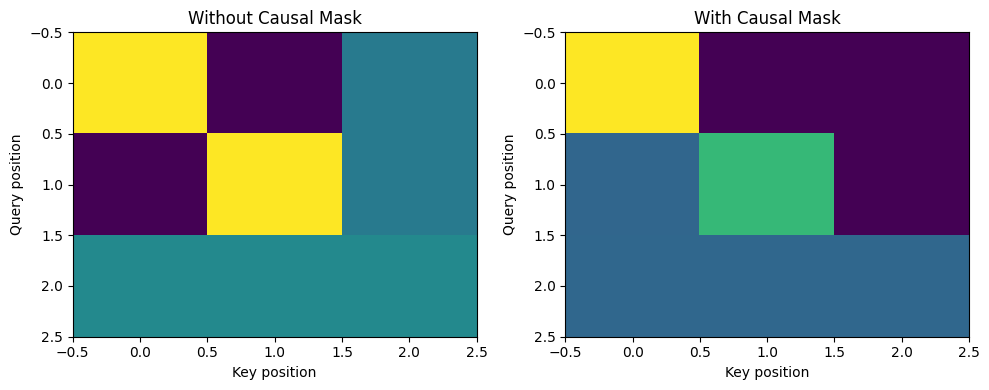

In [16]:
# Attention Weight 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(unmasked_weights.detach().numpy(), aspect="auto")
axes[0].set_title("Without Causal Mask")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

axes[1].imshow(masked_weights.detach().numpy(), aspect="auto")
axes[1].set_title("With Causal Mask")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")

plt.tight_layout()
plt.show()

### 1-2 결과 해석

1. Query index 0은 마스크 적용 후 어느 Key까지 참고할 수 있나요?
   - **답:** 자기 위치인 key index 0까지만 참고한다. 실제 weight는 [1.0, 0.0, 0.0] 이다
2. 마스크 적용 후 Weight 행렬이 삼각형 모양이 되는 이유를 설명해주세요.
   - **답:** Query i는 현재와 과거인 key j <= i 만 볼 수 있어 대각선 위가 모두 0인 상삼각행렬이 된다.
3. Look-ahead Mask를 적용한 위치의 Weight가 0이 되는 과정을 `-∞ → Softmax`와 연결해 서술해주세요.
   - **답:** 가린 score을 -infinite로 바꾸면 softmax에서 exp(-inf)가 0이기 때문에 해당 weight가 0이 된다.
4. Padding Mask와 Look-ahead Mask의 목적의 차이를 한 문장씩 간단하게 작성해주세요.
   - **Padding Mask:** 패딩 토큰을 무시한다.
   - **Look-ahead Mask:** 미래 토큰의 참조를 막는다.


## 1-3. BERT와 GPT의 예측 방식 비교

이제 사전학습 모델을 사용해 두 모델의 차이를 관찰합니다.

- **BERT:** Encoder 기반, 양방향 문맥, Masked Language Model
- **GPT:** Decoder 기반, Causal Mask, 이전 토큰만 이용하는 Autoregressive Language Model

두 모델은 목적이 다르므로 정확도 경쟁이 아니라, **입력과 예측 방식의 차이**를 해석하는 것이 핵심입니다.

In [21]:
import warnings

warnings.filterwarnings('ignore')

In [20]:
# 모델 불러오기
bert_name = "bert-base-uncased"
gpt_name = "gpt2"

# TODO 1: BERT tokenizer와 Masked LM model 불러오기
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForMaskedLM.from_pretrained(bert_name)
_ = bert_model.eval()

# TODO 2: GPT tokenizer와 Causal LM model 불러오기
gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_name)
gpt_model = AutoModelForCausalLM.from_pretrained(gpt_name)
_ = gpt_model.eval()

print("BERT / GPT 모델 로드 완료")


c:\Users\simon\anaconda3\envs\surprise_env\lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\simon\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\simon\anaconda3\envs\surprise_env\lib\site-packages\huggingface_hub\file_download.py:141: UserWarnin

BERT / GPT 모델 로드 완료


In [22]:
# ----- BERT: [MASK]의 앞뒤 문맥을 모두 이용한 단어 예측 -----
# [MASK] 뒤의 "to withdraw money"까지 활용할 수 있다는 점이 핵심
bert_sentence = "I went to the [MASK] to withdraw money."
bert_inputs = bert_tokenizer(bert_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    bert_logits = bert_model(**bert_inputs).logits

mask_positions = (bert_inputs["input_ids"] == bert_tokenizer.mask_token_id).nonzero(as_tuple=False)
assert len(mask_positions) == 1, "[MASK] 토큰은 정확히 하나만 있어야 합니다."
mask_index = mask_positions[0, 1].item()
mask_logits = bert_logits[0, mask_index, :]

# TODO 3: logit이 높은 상위 5개 토큰의 id 구하기
bert_top_ids = torch.topk(mask_logits, 5).indices.tolist()
bert_top_tokens = [bert_tokenizer.decode([idx]).strip() for idx in bert_top_ids]
print("문장:", bert_sentence)
print("BERT top-5 predictions:", bert_top_tokens)


문장: I went to the [MASK] to withdraw money.
BERT top-5 predictions: ['bank', 'banks', 'store', 'atm', 'office']


In [23]:
# ----- GPT: 지금까지의 토큰만 이용한 다음 토큰 예측 -----
# GPT는 뒤 문맥을 볼 수 없으므로, 현재까지 주어진 prefix에서 다음 토큰을 예측
gpt_prompt = "I went to the bank to withdraw"
gpt_inputs = gpt_tokenizer(gpt_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    gpt_logits = gpt_model(**gpt_inputs).logits

next_token_logits = gpt_logits[0, -1, :]

# TODO 4: 다음 토큰 후보 상위 5개의 id 구하기
gpt_top_ids = torch.topk(next_token_logits, 5).indices.tolist()
gpt_top_tokens = [gpt_tokenizer.decode([idx]) for idx in gpt_top_ids]
print("Prompt:", gpt_prompt)
print("GPT next-token top-5:", gpt_top_tokens)


Prompt: I went to the bank to withdraw
GPT next-token top-5: [' money', ' my', ' the', ' $', ' some']


In [24]:
# GPT의 Autoregressive 생성 과정 관찰
prompt = "In natural language processing, Transformer models can"
inputs = gpt_tokenizer(prompt, return_tensors="pt").to(DEVICE)

# TODO 5: max_new_tokens=20, do_sample=False 조건으로 문장 생성
generated_ids = gpt_model.generate(
    **inputs,
    max_new_tokens= 20,
    do_sample= False,
    pad_token_id=gpt_tokenizer.eos_token_id,
)

print(gpt_tokenizer.decode(generated_ids[0], skip_special_tokens=True))


In natural language processing, Transformer models can be used to create a model that is more accurate than the original model.

Transformer models


### 1-3 결과 해석

> **주의:** BERT/GPT의 상위 토큰과 생성 문장은 라이브러리·모델 버전에 따라 조금 달라질 수 있습니다. 반드시 **본인의 실제 출력값을 사용해** 답변을 작성해주시면 됩니다!

1. BERT의 `[MASK]` 상위 5개 예측 중 문맥상 가장 적절하다고 판단한 토큰은 무엇인가요? 그 이유는 무엇인가요?
   - **답:** bank, 뒤 문맥인 to withdraw money까지 함께 보면 돈을 인출하는 장소로 가장 자연스럽다고 생각하기 때문이다.
2. GPT의 다음 토큰 상위 5개 중 자연스럽다고 판단한 후보 2개를 적고, 그 이유도 설명해주세요.
   - **답:** money는 withdraw money를 바로 완성한다. my도 이와 마찬가지로 my money나 my savings 처럼 자연스러운 구를 시작하게 한다.
3. BERT와 GPT의 차이를 **Bidirectional / Causal / Masked Self-Attention** 용어를 사용해 설명해주세요.
   - **답:** Bert는 Bidirectional Self Attention으로 mask의 양쪽 문맥을 전부 본다. GPT는 Causal Mask를 적용한 Masked Self attention으로 현재보다 앞선 토큰만 본다.
4. GPT의 생성 결과를 **Autoregressive** 관점에서 서술해주세요.
   - **답:** GPT는 생성한 토큰을 입력 뒤에 붙여 다음 토큰을 반복 예측하는 autoregressive 방식이다. 실제로 can be used to create a model을 순차적으로 생성했고 마지막에는 transformer models가 반복되었다.


# 2. 심화 과제 (선택)

아래 **A/B 중 하나를 선택**하여 수행하세요. 선택한 실험에서는 코드 실행 결과뿐 아니라 **본인이 관찰한 출력값이나 문장 일부를 근거로 해석**해야 합니다.

---

## A안. BERT의 서로 다른 Attention Head 비교

같은 문장을 넣고 BERT의 동일 Layer 안에서 서로 다른 Head가 **특정 Query 토큰(`it`)에서 어떤 Key 토큰을 참고하는지** 비교합니다.

- 비교 문장: `The animal did not cross the street because it was tired.`
- 비교 Layer: 중간층인 Encoder Layer 8 (0-based index 7)
- 비교 Head: Head 0, Head 1
- 비교 Query: `it`
- 확인할 점: 두 Head가 `it`에서 어떤 토큰에 서로 다른 Attention을 주는지

> 마지막 Layer의 전체 Attention heatmap은 `[SEP]` 같은 특수 토큰에 Attention이 몰려 Head 차이가 잘 안 보일 수 있습니다. 따라서 **중간 Layer + 특정 Query 행**을 비교합니다.


tokens: ['[CLS]', 'the', 'animal', 'did', 'not', 'cross', 'the', 'street', 'because', 'it', 'was', 'tired', '.', '[SEP]']
layer attention shape: torch.Size([12, 14, 14])
query token: it (index 9 )


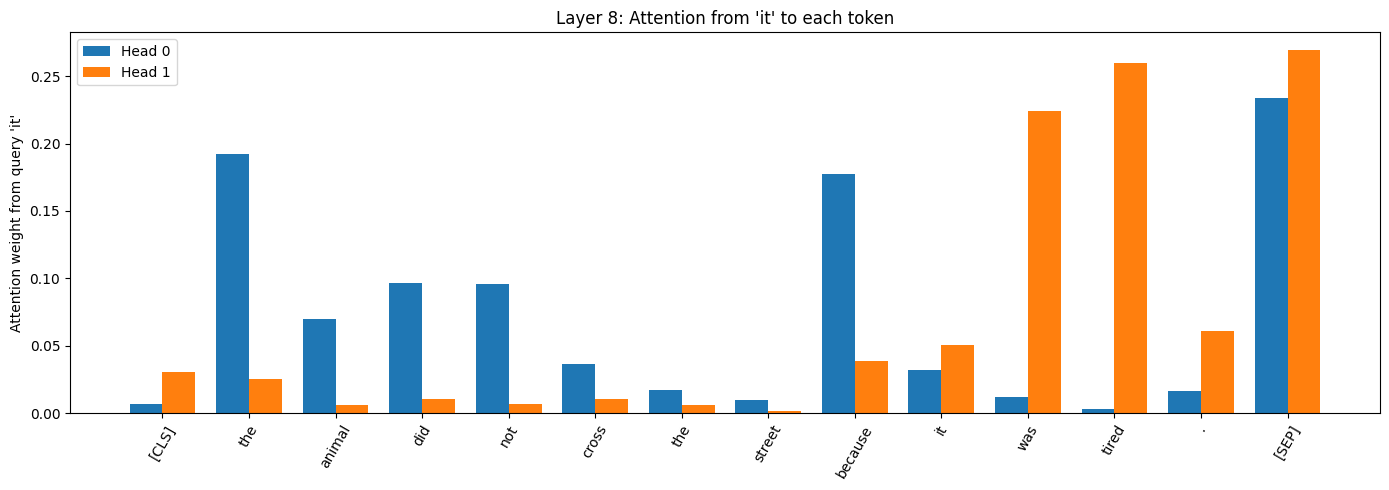

Head 0: 'it'이 가장 크게 참고한 일반 토큰 = 'the' (index=1, weight=0.1923)
Head 1: 'it'이 가장 크게 참고한 일반 토큰 = 'tired' (index=11, weight=0.2598)
Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: 0.084319


In [25]:
# A안: BERT Multi-Head Attention 비교
from transformers import AutoModel

# attention weight를 반환하도록 eager 구현을 사용합니다.
bert_attn_model = AutoModel.from_pretrained(
    bert_name,
    attn_implementation="eager",
).to(DEVICE)
_ = bert_attn_model.eval()

attn_sentence = "The animal did not cross the street because it was tired."
attn_inputs = bert_tokenizer(attn_sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    attn_outputs = bert_attn_model(**attn_inputs, output_attentions=True)

# attentions: tuple(num_layers), 각 원소 shape = [batch, num_heads, seq_len, seq_len]
attentions = attn_outputs.attentions
assert attentions is not None, "Attention이 반환되지 않았습니다. attn_implementation='eager' 설정을 확인하세요."

tokens = bert_tokenizer.convert_ids_to_tokens(attn_inputs["input_ids"][0])

# TODO 1: 8번째 Encoder layer(0-based index 7)를 선택
layer_idx = 7
layer_attn = attentions[layer_idx][0].detach().cpu()

# TODO 2: Query 토큰 'it'의 위치 찾기.
it_idx = tokens.index("it")

# TODO 3: Head 0과 Head 1에서 Query='it'이 모든 Key 토큰에 주는 Attention 가져오기
head0_it = layer_attn[0, it_idx, :]
head1_it = layer_attn[1, it_idx, :]

print("tokens:", tokens)
print("layer attention shape:", layer_attn.shape)
print("query token:", tokens[it_idx], "(index", it_idx, ")")

# 특수 토큰까지 포함한 전체 분포를 막대그래프로 비교
x = np.arange(len(tokens))
width = 0.38
plt.figure(figsize=(14, 5))
plt.bar(x - width/2, head0_it.numpy(), width, label="Head 0")
plt.bar(x + width/2, head1_it.numpy(), width, label="Head 1")
plt.xticks(x, tokens, rotation=60)
plt.ylabel("Attention weight from query 'it'")
plt.title(f"Layer {layer_idx+1}: Attention from 'it' to each token")
plt.legend()
plt.tight_layout()
plt.show()

# 각 Head에서 'it'이 가장 많이 참고한 일반 토큰 확인
# [CLS], [SEP]는 해석을 위해 제외합니다.
special_ids = {0, len(tokens)-1}
valid_indices = [i for i in range(len(tokens)) if i not in special_ids]

def top_key_for_head(weights, valid_indices):
    best = max(valid_indices, key=lambda i: float(weights[i]))
    return best, tokens[best], float(weights[best])

for h, w in [(0, head0_it), (1, head1_it)]:
    idx, tok, val = top_key_for_head(w, valid_indices)
    print(f"Head {h}: 'it'이 가장 크게 참고한 일반 토큰 = {tok!r} (index={idx}, weight={val:.4f})")

mean_abs_diff = torch.mean(torch.abs(head0_it - head1_it)).item()
print(f"Head 0과 Head 1의 'it' attention 분포 평균 절대 차이: {mean_abs_diff:.6f}")


### A안 결과 해석

- **선택:** A
- **변경한 조건:** ? 의미가 어떤건지를 정확히는 파악을 못했지만 todo만 보면 layer8, Query it은 고정한 채로 attention head만 0과 1로 바꿔 비교했다.
- **관찰 결과:** Head 0과 Head 1에서 `it`이 가장 크게 참고한 토큰과 가중치를 각각 실제 출력값을 이용해서 설명해주세요.
head0은 the에 가장 큰 가중치 0.1923을 줬고, head1은 tired에 가장 큰 가중치 0.2598을 줬다. 그래프에서도 head 0은 여러 토큰에 비교적 분산되고 head1은 was와 tired에 집중된다. 두 분포의 평균 절대 차이는 0.083이다.
- **해석:** 두 Head의 Attention 분포가 왜 다를 수 있는지 Multi-Head Attention의 Q/K/V projection과 연결하여 설명하세요.
각 head는 서로 다른 W_Q, W_K, W_V를 학습한다. 따라서 같은 it도 Head마다 다른 Query, Key 공간에서 내적되어 Attention 분포가 달라진다. Q/K가 참고할 토큰과 가중치를 정하고 V는 그 가중치로 결합할 정보를 제공해준다.

---

## B안. GPT Temperature에 따른 생성 다양성 비교

같은 Prompt에서 **temperature만 변경**했을 때 생성 결과의 다양성과 자연스러움이 어떻게 달라지는지 비교합니다.

- Prompt는 모든 실험에서 동일하게 유지합니다.
- `temperature = 0.3, 0.8, 1.5`를 비교합니다.
- 각 temperature에서 **3회 생성**합니다.
- `top_k=50`, 생성 길이 등 나머지 조건은 동일하게 유지합니다.
- 생성 결과의 **다양성(Diversity)** 과 **문맥의 자연스러움(Coherence)** 을 비교합니다.

### 확인할 질문
1. 어느 temperature에서 3개의 생성 결과가 가장 비슷했고, 어느 temperature에서 가장 다양했나요? 실제 생성 문장의 일부를 근거로 설명해세요.
2. temperature가 높아질수록 문장의 자연스러움과 다양성이 어떻게 변했나요? 예상과 다른 결과가 나왔다면 그 결과도 그대로 편하게 적어주세요.
3. temperature가 Softmax 확률분포에 미치는 영향을 위 실험 결과와 연결해 설명하세요.


In [ ]:
# B안: temperature에 따른 GPT 생성 다양성 비교
# 여러 방향으로 자연스럽게 이어질 수 있는 prompt를 사용합니다.
prompt = "Once upon a time, a robot discovered"

# TODO 1: 비교할 temperature 값을 입력
temps = [____, ____, ____]

# top_k, 생성 길이 등은 모든 조건에서 동일하게 고정하고
# temperature만 변경하여 그 효과를 비교합니다.
for temp in temps:
    print(f"\n===== temperature={temp} =====")

    # 같은 temperature에서도 3번 생성하여 결과의 다양성을 확인합니다.
    for trial in range(3):
        # 각 temperature에서 같은 trial끼리는 동일한 seed를 사용합니다.
        torch.manual_seed(SEED + trial)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + trial)

        temp_inputs = gpt_tokenizer(
            prompt,
            return_tensors="pt"
        ).to(DEVICE)

        generated = gpt_model.generate(
            **temp_inputs,
            # TODO 2: 새롭게 생성할 토큰 수를 40으로 설정
            max_new_tokens=____,
            # TODO 3: sampling을 사용하도록 설정
            do_sample=____,
            # TODO 4: 현재 반복문의 temperature를 적용
            temperature=____,
            # 모든 조건에서 동일하게 유지합니다.
            top_k=50,
            pad_token_id=gpt_tokenizer.eos_token_id,
        )

        text = gpt_tokenizer.decode(
            generated[0],
            skip_special_tokens=True
        )

        print(f"\n[생성 {trial + 1}]")
        print(text)


### B안 결과 해석

- **선택:** B
- **변경한 조건:** 어떤 조건을 고정하고 무엇만 변경했는지 작성하세요.
- **관찰 결과:** temperature별 3개의 실제 생성 결과를 비교하고, 구체적인 문장 일부를 인용하세요.
- **해석:** `temperature → Softmax 확률분포 → 다양성/자연스러움`의 관계를 설명하세요.
- **주의:** Sampling 결과는 확률적이므로 이론적인 경향과 완벽하게 일치하지 않을 수 있습니다. 예상과 다른 결과가 나오더라도 실제 출력값을 근거로 타당하게 해석하세요.


# 3. 전체 결과 정리 및 회고

아래 표를 **본인의 실제 실행 결과**를 바탕으로 채워주세요.

| 단계 | 본인이 관찰한 핵심 결과 | 연결되는 개념 |
|---|---|---|
| Attention 직접 구현 | 첫 Query는 Key 0에 가장 큰 가중치 0.4555를 줬고 출력은 여러 value를 결합한 [6.1546, 3.8454]였다 | scaled dot-product attention, softmax, value weighted sum |
| Causal Mask 적용 | Query 0의 Weight가 [1.0, 0.0,  0.0]으로 바뀌어 미래 Key를 보지 못했다. | Causal/Look-ahead Mask, -inf → Softmax 0 |
| BERT 실험 | [MASK]의 상위 예측은 bank, banks, store, atm, office였고, 문맥상 bank가 가장 적절했다. | Bidirectional Self-Attention, Masked Language Model |
| GPT 실험 | 다음 토큰 후보는 money, my, the, $, some이었으며, 실제로 ...can be used to create a model...을 순차 생성했다. | Causal Self-Attention, Next-token Prediction, Autoregressive Generation |

1. **가장 어려웠던 단계와 해결 방법**
   - 답: 사실 Bert, GPT 둘다(애초에 NLP관련) 다뤄본 적이 없는 모듈이라 전반적으로 몰랐다. 문법을 다 찾아가며 구현했다.
2. **실행 전 예상과 실제 결과가 가장 달랐던 부분**
   - 답: 크게 없었던 것 같은데....
3. **기술블로그의 ‘과제 복습’ 섹션에 정리할 핵심 개념**
   - 답: -> 기술블로그에는 TimeSeries를 정리할 거라 아쉽지만 없다..


# 4. 생성형 AI 활용 방법 및 대화 내역

> **반드시 작성하세요.** 문제를 풀면서 GPT, Claude 등 생성형 AI를 어디에 어떻게 사용했는지 기록합니다.

## 1) 활용한 생성형 AI
- 사용한 도구: gemini 
- 사용한 문제/단계: Bert, GPT 모델 쓸떄 문법을 모르겠어서 물어봤다.
- 사용 목적: `개념 확인 / 오류 해결 / 코드 초안 / 결과 해석 / 기타` 코드 초안

## 2) AI 답변을 그대로 사용하지 않고 직접 검증한 방법
- 답: 문법만 물어봤다.  

## 3) AI와의 실제 대화 내역
### 대화 내역

autotokenizer과 automodelformasked/causallm 모듈의 문법과 사용방법 대충 알려줘봐

Hugging Face의 transformers 라이브러리에서 가장 핵심적으로 쓰이는 세 가지 클래스입니다. 이름에 Auto가 붙은 이유는, 모델의 이름만 입력하면 그 구조(Architecture)를 파악해 알아서 알맞은 클래스를 찰떡같이 불러오기 때문입니다.

1. AutoTokenizer: 텍스트 ↔ 숫자 변환기
컴퓨터는 텍스트를 직접 읽을 수 없으므로, 문장을 모델이 이해할 수 있는 숫자(토큰 ID)로 쪼개고 변환해 주는 역할을 합니다.

불러오기: tokenizer = AutoTokenizer.from_pretrained("모델_이름")

입력 인코딩: inputs = tokenizer("Hello world", return_tensors="pt")

return_tensors="pt"는 PyTorch의 텐서 형태로 결과를 반환하라는 뜻입니다.

결과 디코딩: tokenizer.decode(토큰_ID_리스트)

모델이 예측하여 내뱉은 숫자를 다시 사람이 읽을 수 있는 원래 문장으로 되돌려줍니다.

2. AutoModelForMaskedLM: 빈칸 채우기 전문가 (BERT 계열)
문장 중간에 뚫린 구멍을 앞뒤 문맥을 양방향으로 파악하여 알맞은 단어로 채워 넣는 작업(Masked Language Modeling)에 특화된 모델을 불러옵니다.

주요 모델: bert-base-uncased, roberta-base 등

불러오기: model = AutoModelForMaskedLM.from_pretrained("모델_이름")

특징: 모델을 통과시키기 전, 입력 문장 중간에 [MASK]와 같은 특수 토큰이 포함되어 있어야 이 모델의 본래 목적에 맞는 예측 결과를 얻을 수 있습니다.

3. AutoModelForCausalLM: 다음 단어 예측 전문가 (GPT 계열)
지금까지 주어진 텍스트를 바탕으로, 오직 앞쪽 문맥만 보고 그다음에 올 단어를 순차적으로 예측하는 작업(Causal Language Modeling)을 수행하는 모델을 불러옵니다.

주요 모델: gpt2, llama 등

불러오기: model = AutoModelForCausalLM.from_pretrained("모델_이름")

특징: ChatGPT와 같은 텍스트 생성 AI를 만들 때 핵심적으로 사용되며, 모델이 뒤쪽 문맥을 미리 훔쳐볼 수 없도록 훈련 단계부터 마스킹 처리가 되어 있습니다.

핵심 요약:
자연어 처리의 기본 흐름은 항상 Tokenizer로 문장을 숫자로 바꾸고 ➔ 목적에 맞는 AutoModel에 그 숫자를 넣어 연산(예측)한 뒤 ➔ 나온 결과 숫자를 다시 Tokenizer를 통해 텍스트로 바꾸는 사이클로 돌아갑니다.
